# Semantic Benchmark Python Graph and Spectral Analysis

Renders sampled code snippets with graph layers and eigenvalue curves, then renders semantic clone pairs with side-by-side code, graphs, and spectral comparisons.

In [6]:
from pathlib import Path
import html
import json
import pickle
import random
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import HTML, display


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "spectral_code").exists() and (candidate / "pipelines").exists():
            return candidate
    raise RuntimeError("Project root not found.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from spectral_code.evaluation.notebook_helpers import semantic_spec

LANGUAGE = "python"
DISPLAY_LANGUAGE = "Python"
GRAPH_TYPES = ['ast', 'cfg', 'ddg', 'cpg']
PRIMARY_GRAPH_TYPE = "cpg"

spec = semantic_spec(LANGUAGE)
DATA_DIR = spec.data_dir
OUTPUT_ROOT = spec.output_root
REPORTS_DIR = OUTPUT_ROOT / "reports"
GRAPH_MANIFEST_PATH = OUTPUT_ROOT / "clean_graphs" / "graph_shards_manifest.json"
SPECTRAL_MANIFEST_PATH = OUTPUT_ROOT / "spectral_features" / "spectral_features_manifest.json"
PIPELINE_TIMINGS_PATH = OUTPUT_ROOT / "pipeline_timings.json"

print("Project root:", PROJECT_ROOT)
print("Prepared data:", DATA_DIR)
print("Output root:", OUTPUT_ROOT)


Project root: c:\Users\koush\PyProjects\spectrals\Spectral-Software
Prepared data: C:\Users\koush\PyProjects\spectrals\data\semantic_benchmark_prepared\python
Output root: C:\Users\koush\PyProjects\spectrals\outputs\semantic_benchmark\python


In [7]:
def load_code_for_ids(path: Path, wanted_ids: set[str]) -> dict[str, str]:
    code_map = {}
    if not path.exists():
        return code_map
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            method_id = str(row["idx"])
            if method_id in wanted_ids:
                code_map[method_id] = row.get("func", "")
                if len(code_map) == len(wanted_ids):
                    break
    return code_map


def load_graph_manifest() -> dict:
    if not GRAPH_MANIFEST_PATH.exists():
        raise FileNotFoundError(f"Graph manifest not found: {GRAPH_MANIFEST_PATH}. Run ../run_pipeline/02_extract_graphs.py first.")
    return json.loads(GRAPH_MANIFEST_PATH.read_text(encoding="utf-8"))


def load_graphs_for_ids(manifest: dict, wanted_ids: set[str]) -> dict[str, dict[str, nx.DiGraph]]:
    graphs = {}
    for shard_path in manifest.get("shards", []):
        with Path(shard_path).open("rb") as f:
            shard = pickle.load(f)
        for method_id in list(wanted_ids - set(graphs)):
            if method_id in shard:
                graphs[method_id] = shard[method_id]
        if len(graphs) == len(wanted_ids):
            break
    return graphs


def load_spectral_features_for_ids(manifest_path: Path, wanted_ids: set[str]) -> dict[str, dict]:
    if not manifest_path.exists():
        return {}
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    features = {}
    for shard_path in manifest.get("shards", []):
        with Path(shard_path).open("rb") as f:
            shard = pickle.load(f)
        for method_id in list(wanted_ids - set(features)):
            if method_id in shard:
                features[method_id] = shard[method_id]
        if len(features) == len(wanted_ids):
            break
    return features


def draw_graph(graph: nx.DiGraph | None, title: str, ax, max_nodes: int = 100) -> None:
    ax.set_title(title, fontsize=9)
    ax.axis("off")
    if graph is None or graph.number_of_nodes() == 0:
        ax.text(0.5, 0.5, "empty", ha="center", va="center")
        return
    graph = nx.DiGraph(graph)
    shown = graph if graph.number_of_nodes() <= max_nodes else graph.subgraph(list(graph.nodes())[:max_nodes]).copy()
    pos = nx.spring_layout(shown, seed=42)
    nx.draw_networkx_edges(shown, pos, ax=ax, arrows=False, alpha=0.25, width=0.8)
    nx.draw_networkx_nodes(shown, pos, ax=ax, node_size=22, alpha=0.85)
    ax.text(0.01, 0.02, f"{graph.number_of_nodes()} nodes / {graph.number_of_edges()} edges", transform=ax.transAxes, fontsize=7)


def eigenvalues_for(spectral_map: dict, method_id: str, graph_type: str) -> np.ndarray:
    values = spectral_map.get(str(method_id), {}).get(graph_type, {}).get("eigenvalues", [])
    values = np.asarray(values, dtype=np.float64)
    return values[np.isfinite(values)]


def draw_eigenvalues(spectral_map: dict, method_id: str, graph_type: str, ax) -> None:
    values = eigenvalues_for(spectral_map, method_id, graph_type)
    ax.set_title(f"{graph_type.upper()} eigenvalues", fontsize=9)
    if values.size == 0:
        ax.text(0.5, 0.5, "missing", ha="center", va="center", transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
        return
    ax.plot(np.arange(1, values.size + 1), np.sort(values), linewidth=1.2)
    ax.grid(alpha=0.2)
    ax.tick_params(labelsize=8)


def render_code(method_id: str, code_map: dict[str, str], title: str) -> None:
    display(HTML(f"""
    <div style="border:1px solid #d0d7de;border-radius:6px;overflow:hidden;margin:10px 0;">
      <div style="padding:6px 10px;background:#f6f8fa;font-family:system-ui,sans-serif;font-size:13px;">{html.escape(title)} - id {html.escape(str(method_id))}</div>
      <pre style="margin:0;padding:12px;overflow-x:auto;white-space:pre-wrap;font-size:12px;line-height:1.35;max-height:460px;">{html.escape(code_map.get(str(method_id), ""))}</pre>
    </div>
    """))


def render_code_pair(left_id: str, right_id: str, code_map: dict[str, str], title: str) -> None:
    display(HTML(f"""
    <h3>{html.escape(title)}</h3>
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;align-items:start;">
      <div><b>left id: {html.escape(str(left_id))}</b><pre style="white-space:pre-wrap;font-size:12px;line-height:1.35;border:1px solid #d0d7de;padding:10px;border-radius:6px;max-height:460px;overflow:auto;">{html.escape(code_map.get(str(left_id), ""))}</pre></div>
      <div><b>right id: {html.escape(str(right_id))}</b><pre style="white-space:pre-wrap;font-size:12px;line-height:1.35;border:1px solid #d0d7de;padding:10px;border-radius:6px;max-height:460px;overflow:auto;">{html.escape(code_map.get(str(right_id), ""))}</pre></div>
    </div>
    """))


In [8]:
def stage_runtime_row(stage: str) -> dict:
    timings = json.loads(PIPELINE_TIMINGS_PATH.read_text(encoding="utf-8")) if PIPELINE_TIMINGS_PATH.exists() else {"stages": {}}
    record = timings.get("stages", {}).get(stage, {})
    seconds = record.get("seconds")
    minutes = record.get("minutes")
    if minutes is None and isinstance(seconds, (int, float)):
        minutes = seconds / 60
    return {
        "stage": stage,
        "seconds": round(seconds, 2) if isinstance(seconds, (int, float)) else None,
        "minutes": round(minutes, 2) if isinstance(minutes, (int, float)) else None,
        "updated_at_utc": record.get("updated_at_utc"),
        "status": "recorded" if isinstance(seconds, (int, float)) else "not recorded yet",
        "source": str(PIPELINE_TIMINGS_PATH),
    }


Graph methods: 2000
Spectral features: C:\Users\koush\PyProjects\spectrals\outputs\semantic_benchmark\python\spectral_features\spectral_features_manifest.json
Single method examples: ['30407', '30383']
Clone pairs: [('30047', '30048', 1), ('31529', '31530', 1)]
Loaded code snippets: 6
Loaded graph records: 6
Loaded spectral feature records: 6


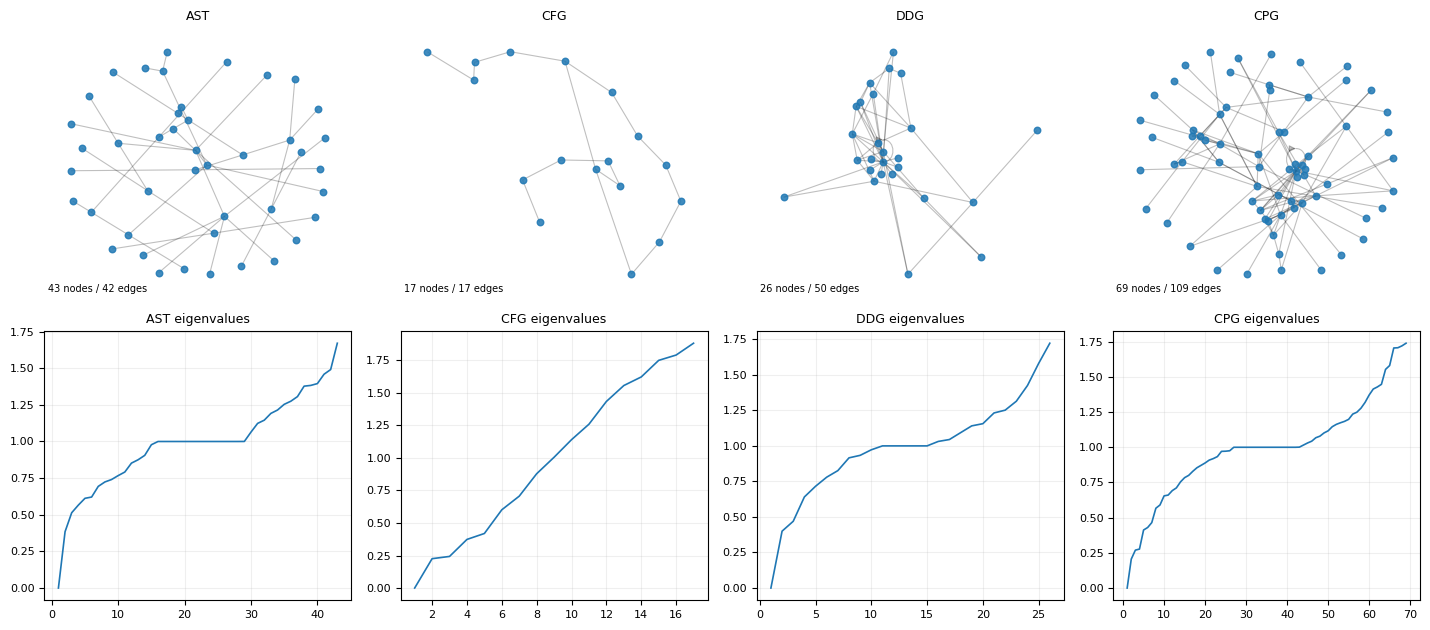

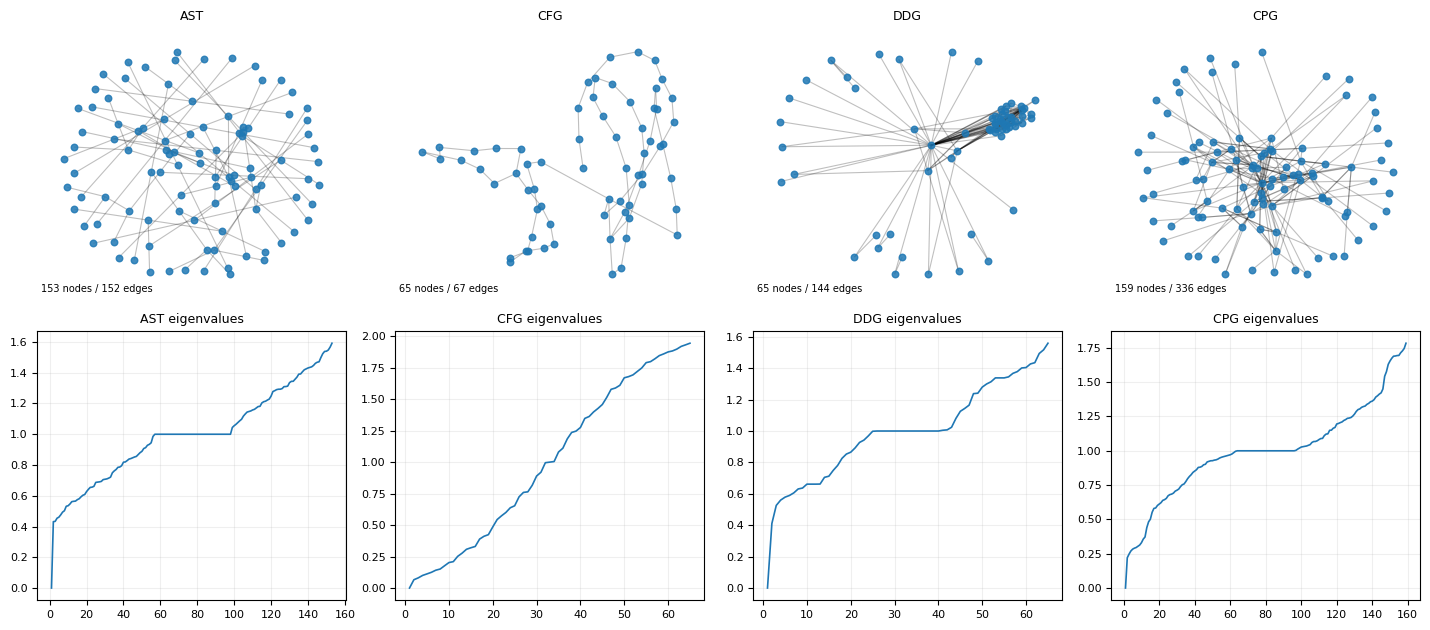

In [9]:
manifest = load_graph_manifest()
print("Graph methods:", manifest.get("total_methods"))
print("Spectral features:", SPECTRAL_MANIFEST_PATH if SPECTRAL_MANIFEST_PATH.exists() else "not found yet")


def sample_method_ids(path: Path, n: int, seed: int) -> list[str]:
    rng = random.Random(seed)
    selected = []
    seen = 0
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            method_id = str(json.loads(line)["idx"])
            seen += 1
            if len(selected) < n:
                selected.append(method_id)
                continue
            slot = rng.randrange(seen)
            if slot < n:
                selected[slot] = method_id
    return selected


def sample_pairs(path: Path, label: int, n: int, seed: int) -> list[tuple[str, str, int]]:
    rng = random.Random(seed)
    selected = []
    seen = 0
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            left, right, raw_label = line.rstrip("\n").split("\t")[:3]
            raw_label = int(raw_label)
            if raw_label != label:
                continue
            seen += 1
            row = (left, right, raw_label)
            if len(selected) < n:
                selected.append(row)
                continue
            slot = rng.randrange(seen)
            if slot < n:
                selected[slot] = row
    return selected


single_method_ids = sample_method_ids(DATA_DIR / "data.jsonl", 2, seed=42)
clone_pairs = sample_pairs(DATA_DIR / "train.txt", label=1, n=2, seed=43)
needed_ids = set(single_method_ids)
for pair in clone_pairs:
    needed_ids.update(pair[:2])

code_map = load_code_for_ids(DATA_DIR / "data.jsonl", needed_ids)
graph_map = load_graphs_for_ids(manifest, needed_ids)
spectral_map = load_spectral_features_for_ids(SPECTRAL_MANIFEST_PATH, needed_ids)

print("Single method examples:", single_method_ids)
print("Clone pairs:", clone_pairs)
print("Loaded code snippets:", len(code_map))
print("Loaded graph records:", len(graph_map))
print("Loaded spectral feature records:", len(spectral_map))

for idx, method_id in enumerate(single_method_ids, start=1):
    render_code(method_id, code_map, f"Single code example {idx}")
    fig, axes = plt.subplots(2, len(GRAPH_TYPES), figsize=(3.6 * len(GRAPH_TYPES), 6.4), squeeze=False)
    for col, graph_type in enumerate(GRAPH_TYPES):
        draw_graph(graph_map.get(method_id, {}).get(graph_type), graph_type.upper(), axes[0][col])
        draw_eigenvalues(spectral_map, method_id, graph_type, axes[1][col])
    plt.tight_layout()
    plt.show()


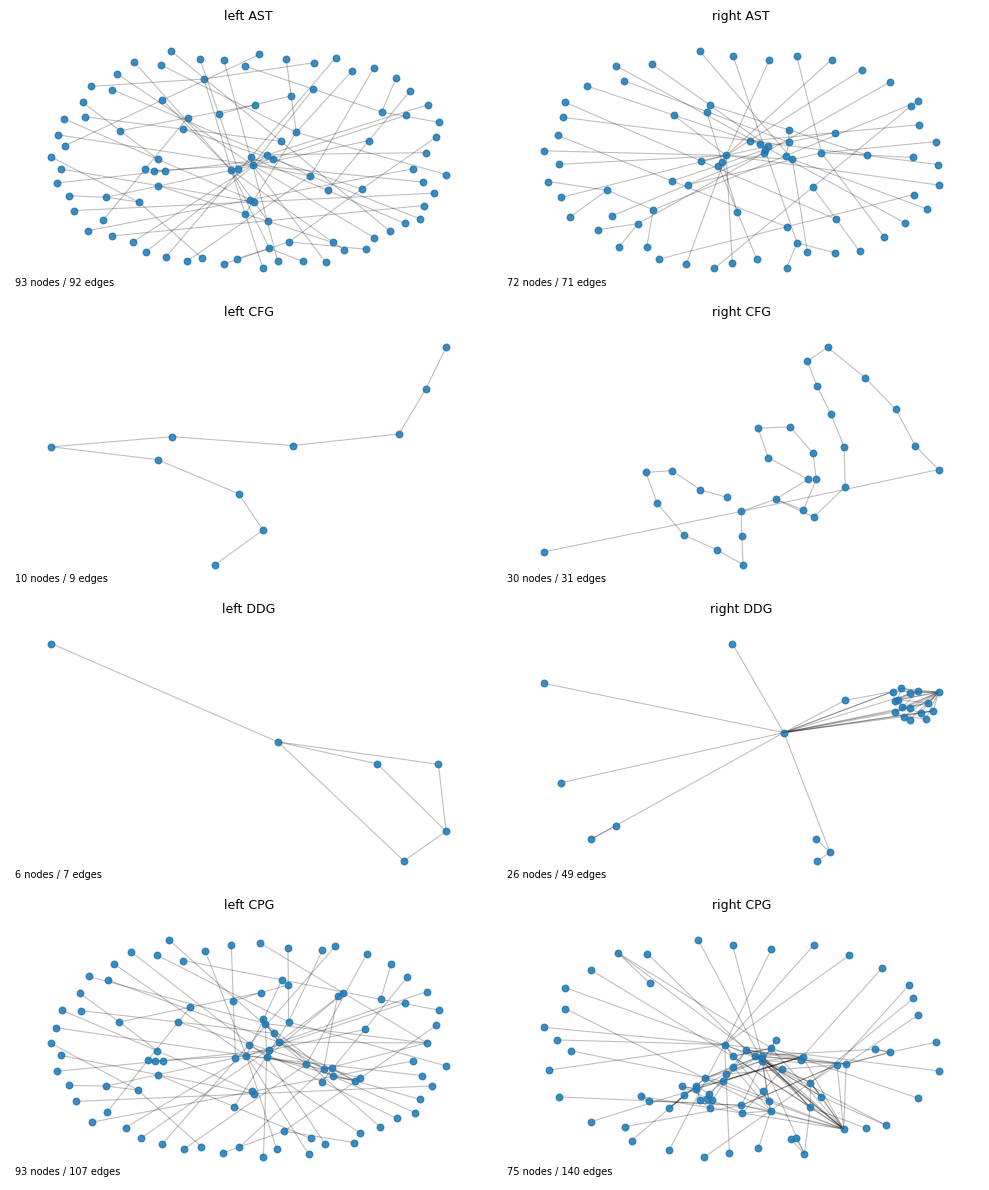

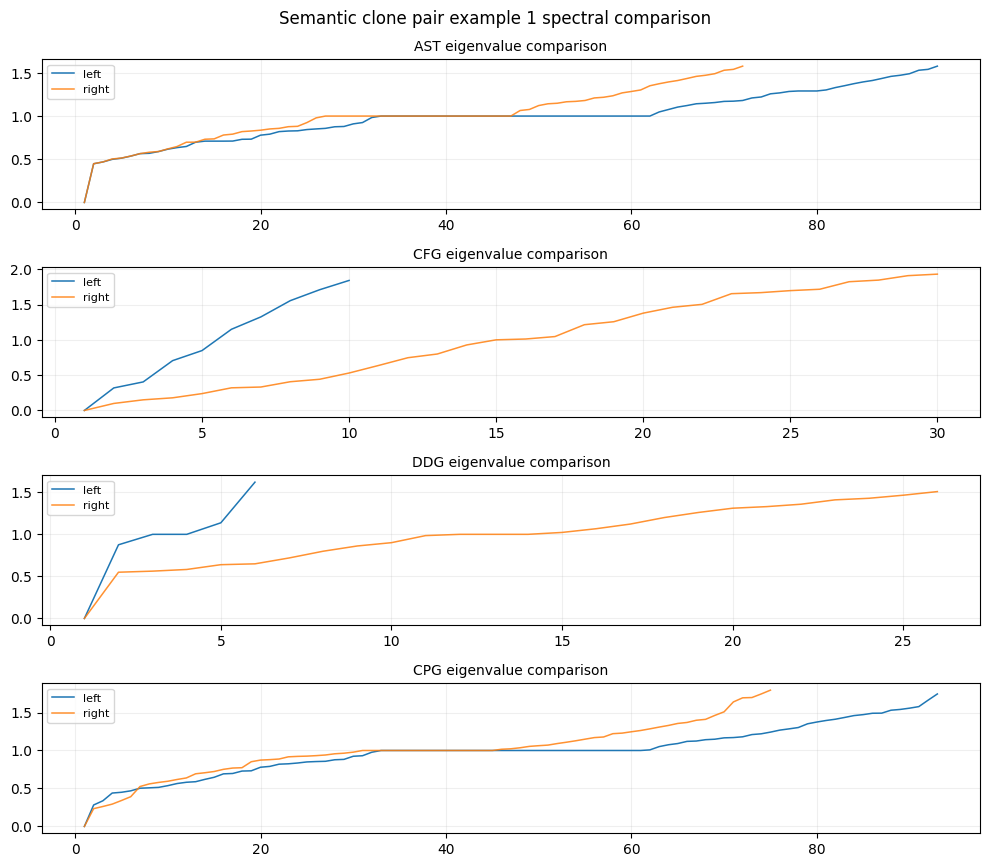

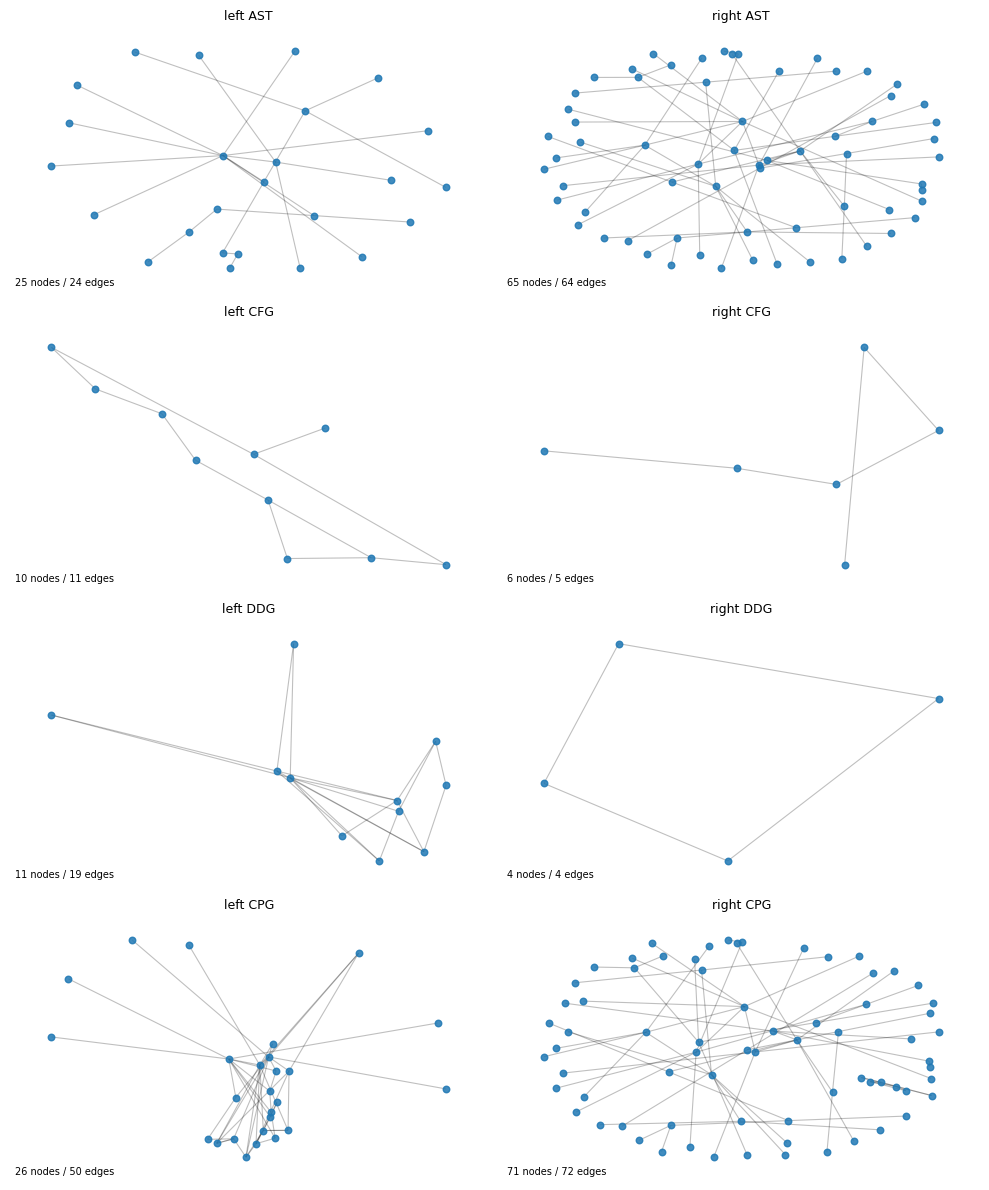

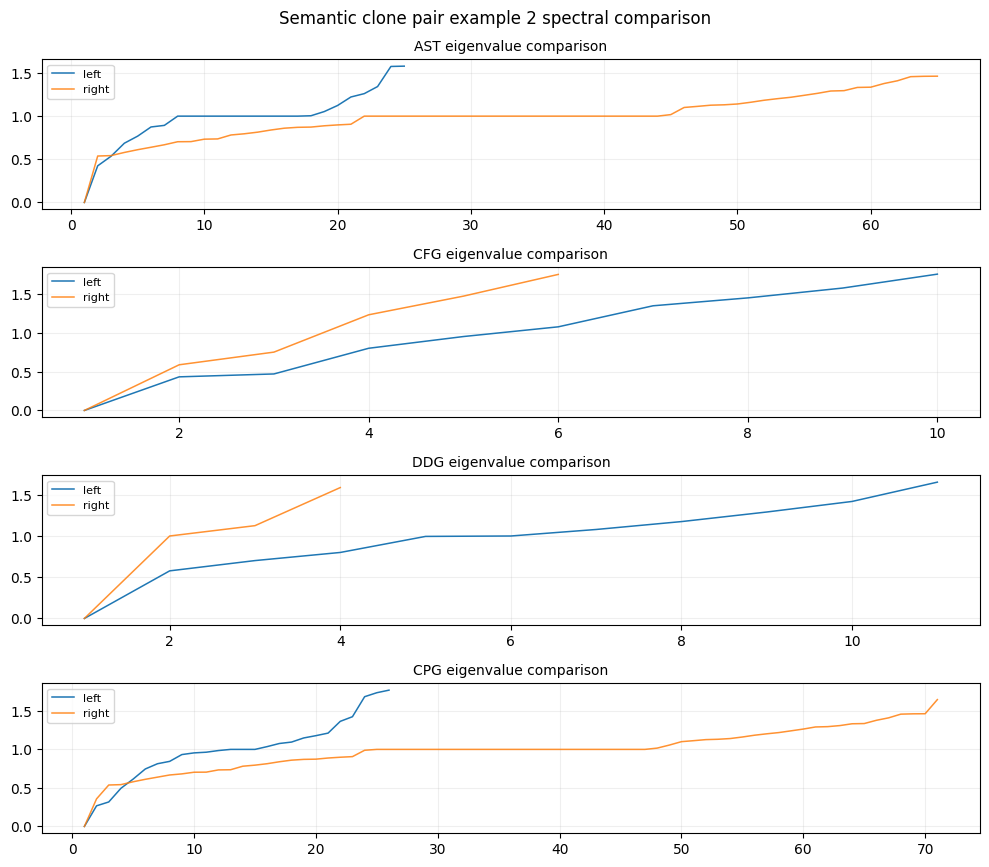

,stage,seconds,minutes,updated_at_utc,status,source
0,02_extract_graphs,132.42,2.21,2026-07-04T16:11:49+00:00,recorded,C:\Users\koush\PyProjects\spectrals\outputs\se...
1,03_extract_spectral_features,34.29,0.57,2026-07-04T16:12:27+00:00,recorded,C:\Users\koush\PyProjects\spectrals\outputs\se...


In [10]:
def draw_pair(pair: tuple[str, str, int] | None, title: str) -> None:
    if pair is None:
        display(HTML(f"<b>{html.escape(title)}</b>: no matching pair found."))
        return
    left_id, right_id, label = pair
    render_code_pair(left_id, right_id, code_map, f"{title} - label {label}")
    fig, axes = plt.subplots(len(GRAPH_TYPES), 2, figsize=(10, max(8, 3.0 * len(GRAPH_TYPES))), squeeze=False)
    for row, graph_type in enumerate(GRAPH_TYPES):
        draw_graph(graph_map.get(left_id, {}).get(graph_type), f"left {graph_type.upper()}", axes[row][0])
        draw_graph(graph_map.get(right_id, {}).get(graph_type), f"right {graph_type.upper()}", axes[row][1])
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(len(GRAPH_TYPES), 1, figsize=(10, max(6, 2.2 * len(GRAPH_TYPES))), squeeze=False)
    for ax, graph_type in zip(axes[:, 0], GRAPH_TYPES):
        left_values = eigenvalues_for(spectral_map, left_id, graph_type)
        right_values = eigenvalues_for(spectral_map, right_id, graph_type)
        ax.set_title(f"{graph_type.upper()} eigenvalue comparison", fontsize=10)
        if left_values.size:
            ax.plot(np.arange(1, left_values.size + 1), np.sort(left_values), label="left", linewidth=1.1)
        if right_values.size:
            ax.plot(np.arange(1, right_values.size + 1), np.sort(right_values), label="right", linewidth=1.1, alpha=0.85)
        if not left_values.size and not right_values.size:
            ax.text(0.5, 0.5, "missing", ha="center", va="center", transform=ax.transAxes)
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)
    fig.suptitle(f"{title} spectral comparison")
    plt.tight_layout()
    plt.show()


for idx, pair in enumerate(clone_pairs, start=1):
    draw_pair(pair, f"Semantic clone pair example {idx}")
display(pd.DataFrame([stage_runtime_row("02_extract_graphs"), stage_runtime_row("03_extract_spectral_features")]))
